In [ ]:
"""
Backpropagating error to the parameters and then updating those parameters by taking the 
gradient with respect to the loss is going to be the same no matter what the underlying 
model is (figure 5.1).

In this chapter, you’re going to make changes in your model architecture.
You’re going to implement a full artificial neural network to solve your problem.

Your thermometer conversion training loop and Fahrenheit-to-Celsius samples split
into training and validation sets remain. You could start to use a quadratic model,
rewriting your model as a quadratic function of its input (such as y = a * x**2 + b *
x + c). Because such a model would be differentiable, PyTorch would take care of
computing gradients, and the training loop would work as usual. That wouldn’t be too
interesting for you, though, because you’d still be fixing the shape of the function.

5.1 Artificial neurons
The basic building block of these complicated functions is the neuron, pictured in
figure 5.2. At its core, a neuron is nothing but a linear transformation of the input
(such as multiplication of the input by a number [the weight] and the addition of a
constant [the bias]) followed by the application of a fixed nonlinear function
(referred to as the activation function).

Mathematically, you can write this as o = f(w * x + b), with x as the input, w as
the weight or scaling factor, and b as the bias or offset. f is the activation function, set
to the hyperbolic tangent or “tanh” function here. In general, x and hence o can be
simple scalars, or vector-valued (holding many scalar values). Similarly, w can be a single
scalar, or a matrix, whereas b is a scalar or vector (the dimensionality of the inputs
and weights must match, however). In the latter case, the expression is referred to as a
layer of neurons because it represents many neurons via the multidimensional weights
and biases.

A multilayer neural network, as represented in figure 5.3, is a composition of the
preceding functions:
x_1 = f(w_0 * x + b_0)
x_2 = f(w_1 * x_1 + b_1)
...
y = f(w_n * x_n + b_n)

where the output of a layer of neurons is used as an input for the following layer.
Remember that w_0 here is a matrix, and x is a vector! Using a vector here allows w_0
to hold an entire layer of neurons, not just a single weight.

An important difference between the earlier linear model and what you’ll be using for
deep learning is the shape of the error function. The linear model and error-squared loss
function had a convex error curve with a singular, clearly defined minimum. If you were
to use other methods, you could solve for it automatically and definitively. Your parameter
updates were attempting to estimate that singular correct answer as best they could.

Neural networks don’t have that same property of a convex error surface, even
when using the same error-squared loss function. There’s no single right answer for
each parameter that you’re attempting to approximate. Instead, you’re trying to get
all the parameters, when acting in concert, to produce useful output. Since that useful
output is only going to approximate the truth, there will be some level of imperfection.
Where and how those imperfections manifest is somewhat arbitrary, and by
implication the parameters that control the output (and hence the imperfections) are
somewhat arbitrary as well. This output results in neural network training’s looking
much like parameter estimation from a mechanical perspective, but you must remember
that the theoretical underpinnings are quite different.

A big part of the reason why neural networks have nonconvex error surfaces is due
to the activation function. The ability of an ensemble of neurons to approximate a
wide range of useful functions depends on the combination of the linear and nonlinear
behavior inherent to each neuron.

5.1.1 All you need is activation
The simplest unit in (deep) neural networks is a linear operation (scaling + offset) followed
by an activation function. You had a linear operation in your latest model; the
linear operation was the entire model. The activation function has the role of concentrating
the outputs of the preceding linear operation into a given range.

Suppose that you’re assigning a “good doggo” score to images. Pictures of retrievers
and spaniels should have a high score; images of airplanes and garbage trucks
should have a low score. Bear pictures should have a low-ish score too, though higher
than garbage trucks.

The problem is that you have to define a high score. Because you’ve got the entire
range of float32 to work with, you can go pretty high. Even if you say “It’s a ten point
scale,” sometimes your model is going to produce a score of 11 out of 10. Remember
that under the hood, it’s all sum of w*x+b matrix multiplications, which won’t naturally
limit themselves to a specific range of outputs.

What you want to do is firmly constrain the output of your linear operation to a
specific range so that the consumer of this output isn’t having to handle numerical
inputs of puppies at 12/10, bears at -10, and garbage trucks at -1000.
One possibility is to cap the output values. Anything below zero is set to zero, and
anything above 10 is set to 10. You use a simple activation function called
torch.nn.Hardtanh.2

2 See https://pytorch.org/docs/stable/nn.html#hardtanh, but note that the default range is -1 to +1.

Another family of functions that works well is torch.nn.Sigmoid, which is 1 / (1
+ e ** -x), torch.tanh, and others that you’ll see in a moment. These functions
have a curve that asymptotically approaches zero or negative one as x goes to negative
infinity, approaches one as x increases, and has a mostly constant slope at x == 0. Conceptually,
functions shaped this way work well, because it means that your neuron
(which, again, is a linear function followed by an activation) will be sensitive to an area
in the middle of your linear function’s output; everything else gets lumped up next to
the boundary values. As you see in figure 5.4, a garbage truck gets a score of -0.97,
whereas bears, foxes, and wolves may end up somewhere in the -0.3 to 0.3 range.

Garbage trucks are flagged as “not dogs,” the good dog maps to “clearly a dog,” and
the bear ends up somewhere in the middle. In code, you see the exact values:

Refer : Figure 5.4.1 code looks like.png

"""

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
import torch.nn as nn

torch.set_printoptions(edgeitems=2, linewidth=75)

In [2]:
input_t = torch.arange(-3, 3.1, 0.1)
input_t

tensor([-3.0000e+00, -2.9000e+00, -2.8000e+00, -2.7000e+00, -2.6000e+00,
        -2.5000e+00, -2.4000e+00, -2.3000e+00, -2.2000e+00, -2.1000e+00,
        -2.0000e+00, -1.9000e+00, -1.8000e+00, -1.7000e+00, -1.6000e+00,
        -1.5000e+00, -1.4000e+00, -1.3000e+00, -1.2000e+00, -1.1000e+00,
        -1.0000e+00, -9.0000e-01, -8.0000e-01, -7.0000e-01, -6.0000e-01,
        -5.0000e-01, -4.0000e-01, -3.0000e-01, -2.0000e-01, -1.0000e-01,
        -2.3842e-08,  1.0000e-01,  2.0000e-01,  3.0000e-01,  4.0000e-01,
         5.0000e-01,  6.0000e-01,  7.0000e-01,  8.0000e-01,  9.0000e-01,
         1.0000e+00,  1.1000e+00,  1.2000e+00,  1.3000e+00,  1.4000e+00,
         1.5000e+00,  1.6000e+00,  1.7000e+00,  1.8000e+00,  1.9000e+00,
         2.0000e+00,  2.1000e+00,  2.2000e+00,  2.3000e+00,  2.4000e+00,
         2.5000e+00,  2.6000e+00,  2.7000e+00,  2.8000e+00,  2.9000e+00,
         3.0000e+00])

tensor([-3.0000e-01, -2.9000e-01, -2.8000e-01, -2.7000e-01, -2.6000e-01,
        -2.5000e-01, -2.4000e-01, -2.3000e-01, -2.2000e-01, -2.1000e-01,
        -2.0000e-01, -1.9000e-01, -1.8000e-01, -1.7000e-01, -1.6000e-01,
        -1.5000e-01, -1.4000e-01, -1.3000e-01, -1.2000e-01, -1.1000e-01,
        -1.0000e-01, -9.0000e-02, -8.0000e-02, -7.0000e-02, -6.0000e-02,
        -5.0000e-02, -4.0000e-02, -3.0000e-02, -2.0000e-02, -1.0000e-02,
        -2.3842e-09,  1.0000e-01,  2.0000e-01,  3.0000e-01,  4.0000e-01,
         5.0000e-01,  6.0000e-01,  7.0000e-01,  8.0000e-01,  9.0000e-01,
         1.0000e+00,  1.1000e+00,  1.2000e+00,  1.3000e+00,  1.4000e+00,
         1.5000e+00,  1.6000e+00,  1.7000e+00,  1.8000e+00,  1.9000e+00,
         2.0000e+00,  2.1000e+00,  2.2000e+00,  2.3000e+00,  2.4000e+00,
         2.5000e+00,  2.6000e+00,  2.7000e+00,  2.8000e+00,  2.9000e+00,
         3.0000e+00])

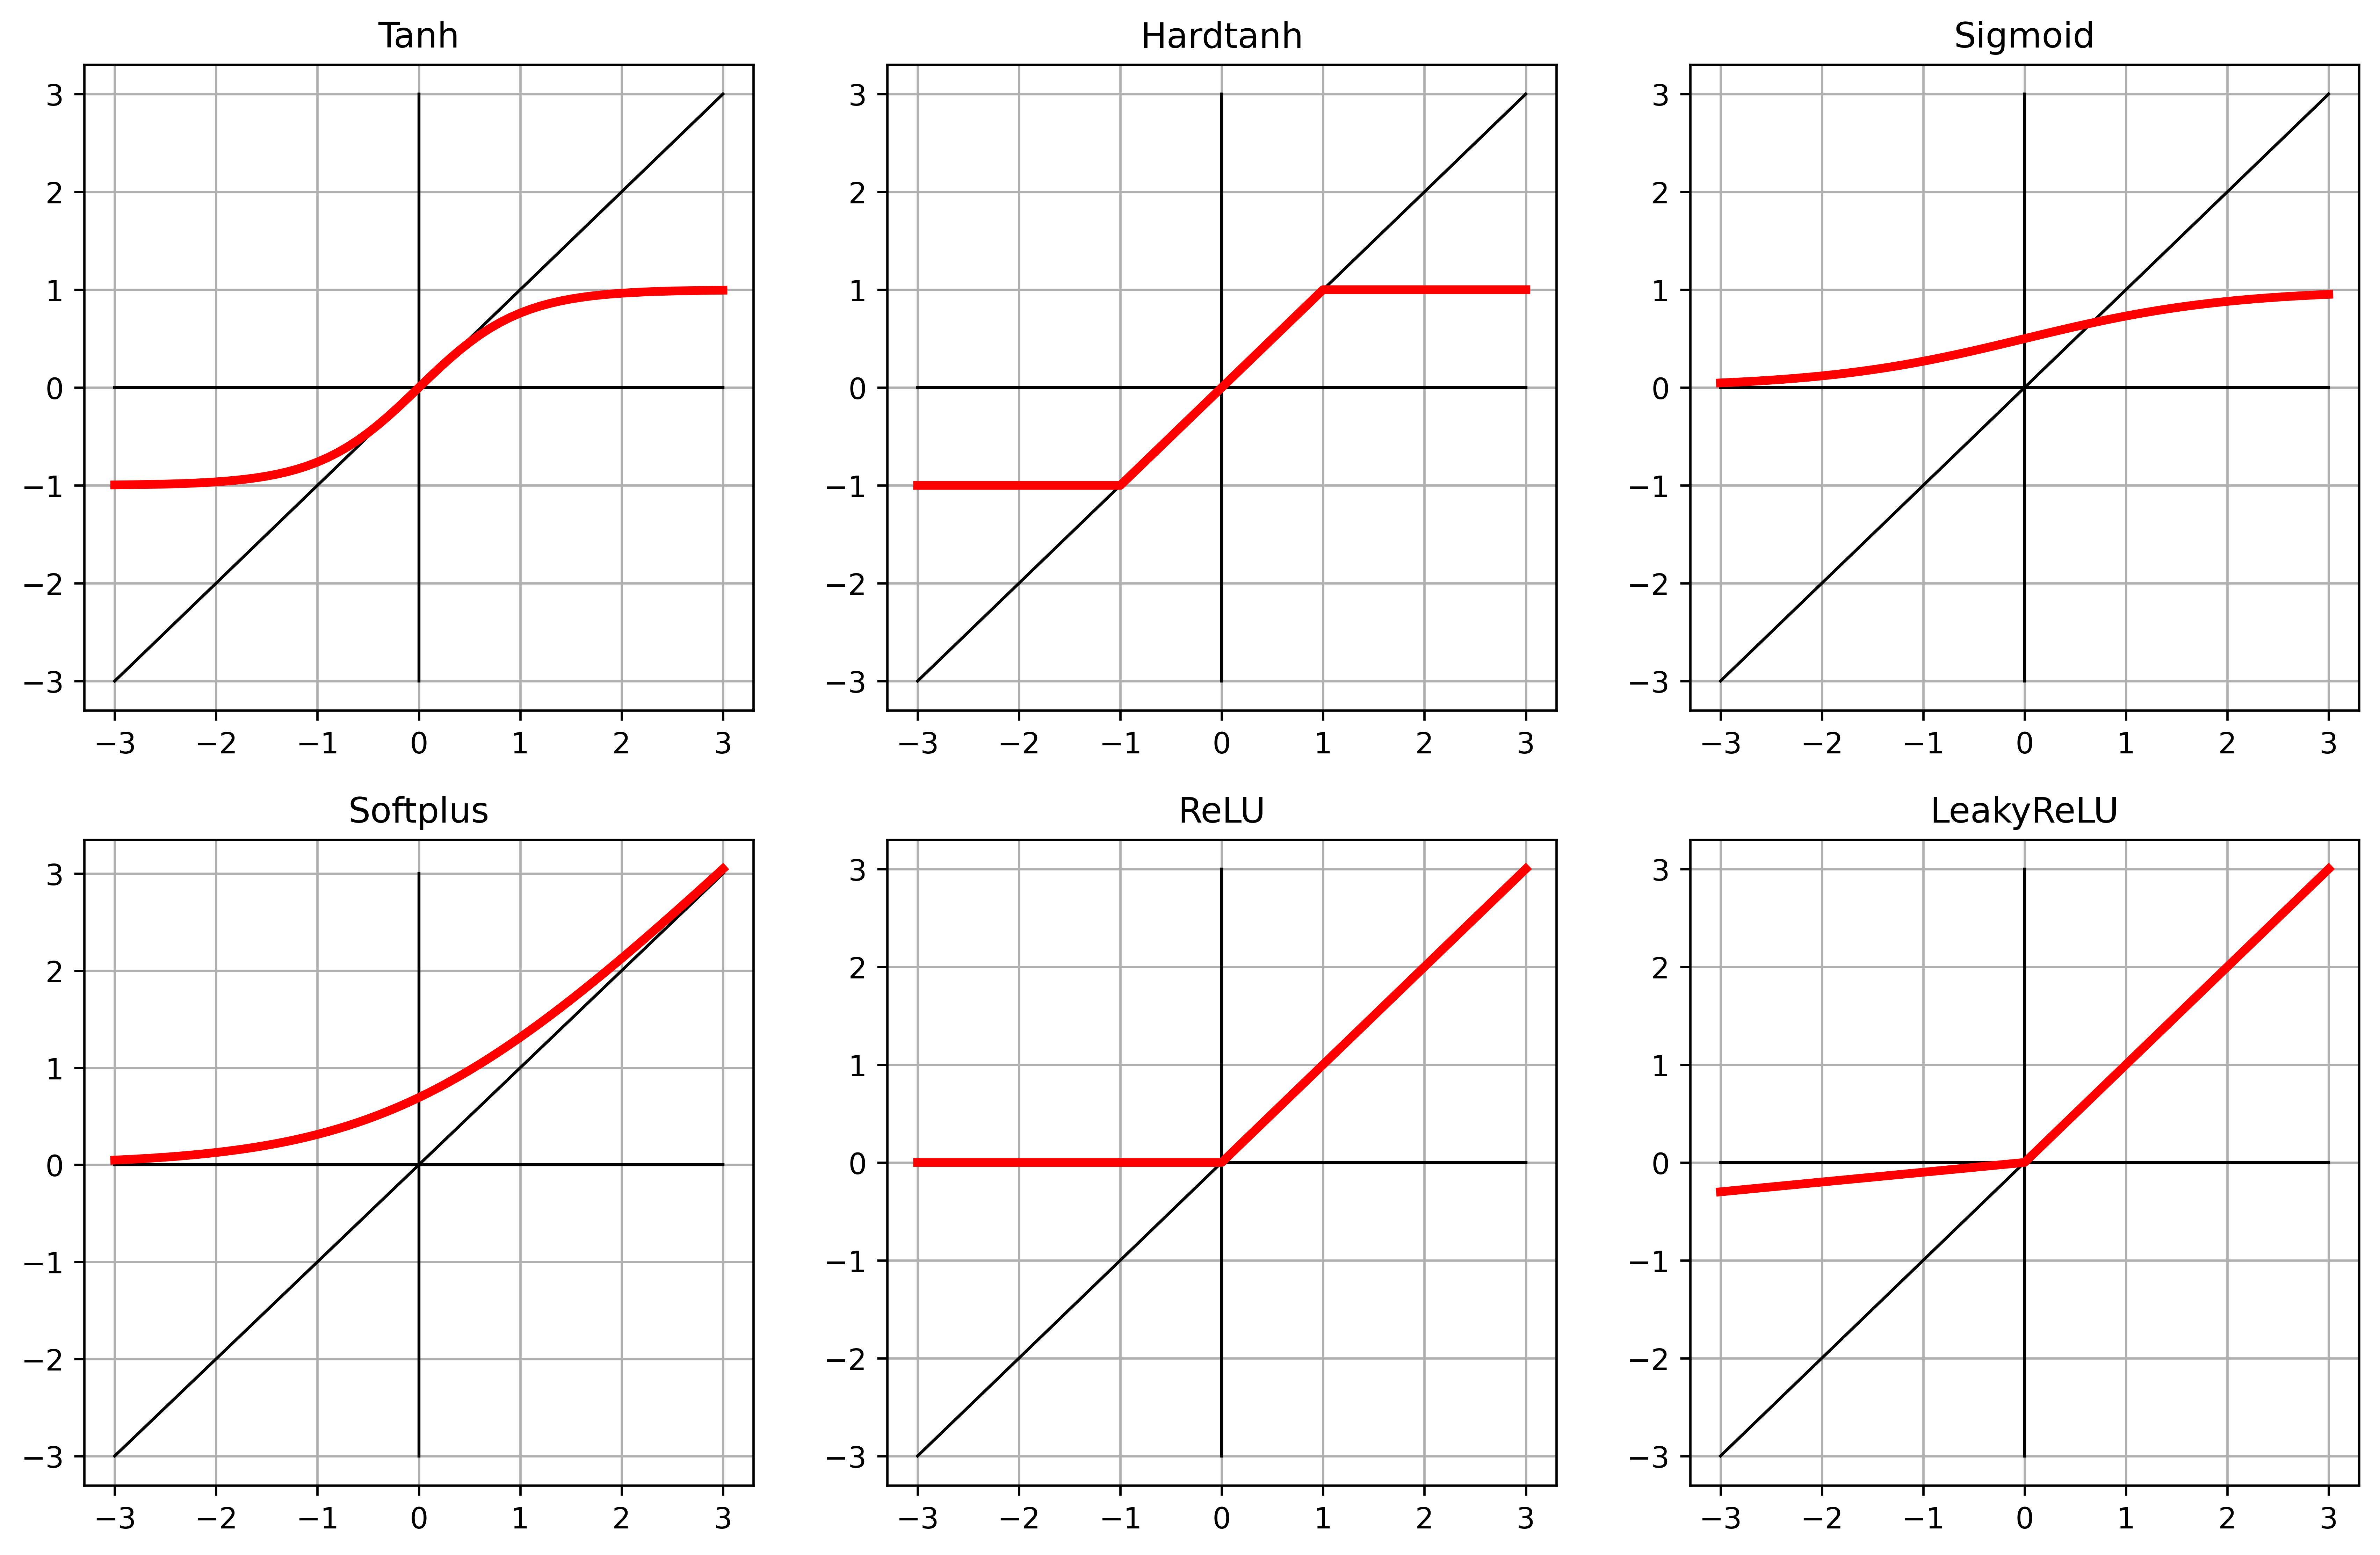

In [3]:
activation_list = [
    nn.Tanh(),
    nn.Hardtanh(),
    nn.Sigmoid(),
    
    nn.Softplus(),
    nn.ReLU(),
    nn.LeakyReLU(negative_slope=0.1),

    
    #nn.Tanhshrink(),
    #nn.Softshrink(),
    #nn.Hardshrink(),
]

fig = plt.figure(figsize=(14, 28), dpi=600)

for i, activation_func in enumerate(activation_list):
    subplot = fig.add_subplot(len(activation_list), 3, i+1)
    subplot.set_title(type(activation_func).__name__)
    
    output_t = activation_func(input_t)
    
    plt.grid()
    plt.plot(input_t.numpy(), input_t.numpy(),'k', linewidth=1)
    plt.plot([-3,3], [0,0], 'k', linewidth=1)
    plt.plot([0,0], [-3,3], 'k', linewidth=1)
    plt.plot(input_t.numpy(), output_t.numpy(), 'r', linewidth=3)

output_t

In [ ]:
"""
With the bear in the sensitive range, small changes to the bear result in a noticeable
change in the result. You could swap from a grizzly to a polar bear (which has a
vaguely more traditionally canine face) and see a jump up the Y axis as you slide
toward the “very much a dog” end of the graph. Conversely, a koala bear would register
as less doglike and would see a drop in the activated output. There isn’t much you
could do to the garbage truck to make it register as doglike, though. Even with drastic
changes, you might see a shift only from -0.97 to -0.8 or so.

Quite a few activation functions are available, some of which are pictured in figure
5.5. In the first column, you see the continuous functions Tanh and Softplus; the second
column has “hard” versions of the activation functions to their left, Hardtanh and
ReLU. ReLU (Rectified Linear Unit) deserves special note, as it is currently considered
to be one of the best-performing general activation functions, as many state-of-the-art
results have used it. The Sigmoid activation function, also known as the logistic func-
tion, was widely used in early deep learning work but has fallen out of common use.
Finally, the LeakyReLU function modifies the standard ReLU to have a small positive
slope rather than being strictly zero for negative inputs. (Typically, this slope is 0.01,
but it’s shown here with slope 0.1 for clarity.)

Activation functions are curious, because with such a wide variety of proven-successful
ones (many more than pictured in figure 5.5), it’s clear that there are few, if
any, strict requirements. As such, we’re going to discuss some generalities about activation
functions that can probably be disproved in the specific. That said, by definition,
activation functions.3

3 Even these statements aren’t always true, of course: 
See https://openai.com/research/nonlinear-computation-in-deep-linear-networks

􀂃 Are nonlinear— Repeated applications of w*x+b without an activation function
  results in a polynomial. The nonlinearity allows the overall network to approximate
  more complex functions.
􀂃 Are differentiable—They’re differentiable so that gradients can be computed
  through them. Point discontinuities, as you see in Hardtanh or ReLU, are fine.
  
Without those functions, the network either falls back to being a complicated polynomial
or becomes difficult to train.

Also generally true (though less so), the functions:
􀂃 Have at least one sensitive range, where no-trivial changes to the input result in
  a corresponding nontrivial change in the output.
􀂃 Have at least one insensitive (or saturated) range, where changes to the input
  result in little to no change in the output.

By way of example, the Hardtanh function could easily be used to make piecewise-linear
approximations of a function due to combining the sensitive range with different
weights and biases on the input.

Often (but far from universally so), the activation function has at least one of the
following:
􀂃 A lower bound that is approached (or met) as the input goes to negative infinity
􀂃 A similar-but-inverse upper bound for positive infinity

Thinking about what you know about how backpropagation works, you can figure out
that the errors will propagate backward through the activation more effectively when
the inputs are in the response range, whereas errors won’t greatly affect neurons for
which the input is saturated (because the gradient will be close to zero due to the flat
area around the output).

All put together, this mechanism is pretty powerful. What we’re saying is that in a
network built out of linear + activation units, when different inputs are presented to
the network, 
(a) different units respond in different ranges for the same inputs, and
(b) the errors associated with those inputs will primarily affect the neurons operating
    in the sensitive range, leaving other units more or less unaffected by the learning process.
In addition, thanks to the fact that derivatives of the activation with respect to its
inputs are often close to one in the sensitive range, estimating the parameters of the
linear transformation through gradient descent for the units that operate in that
range will look a lot like the linear fit.

You’re starting to get a deeper intuition about how joining many linear + activation
units in parallel and stacking them one after the other leads to a mathematical object
that is capable of approximating complicated functions. Different combinations of
units respond to inputs in different ranges and for those parameters are relatively easy
to optimize through gradient descent, because learning will behave a lot like that of a
linear function until the output saturates.

5.1.2 What learning means for a neural network
Building models out of stacks of linear transformations followed by differentiable activations
leads to models that can approximate highly nonlinear processes whose
parameters you can estimate surprisingly well through gradient descent. This fact
remains true even when you’re dealing with models with millions of parameters. What
makes using deep neural networks so attractive is that it allows you not to worry too
much about the exact function that represents your data, whether it’s quadratic,
piecewise polynomial, or something else. With a deep neural network model, you
have a universal approximator and a method to estimate its parameters. This approximator
can be customized to your needs, in terms of model capacity and its ability to
model complicated input/output relationships, by composing simple building blocks.

Figure 5.6 shows some examples.



"""

tensor([1.6885, 1.6924, 1.6967, 1.7015, 1.7064, 1.7112, 1.7155, 1.7184,
        1.7190, 1.7158, 1.7069, 1.6901, 1.6629, 1.6229, 1.5685, 1.5005,
        1.4238, 1.3486, 1.2913, 1.2713, 1.3060, 1.4017, 1.5384, 1.6643,
        1.7191, 1.6667, 1.5191, 1.3410, 1.2022, 1.1303, 1.1191, 1.1508,
        1.2075, 1.2744, 1.3414, 1.4024, 1.4547, 1.4979, 1.5328, 1.5605,
        1.5824, 1.5997, 1.6132, 1.6239, 1.6324, 1.6391, 1.6444, 1.6487,
        1.6521, 1.6549, 1.6571, 1.6589, 1.6604, 1.6615, 1.6625, 1.6633,
        1.6639, 1.6644, 1.6649, 1.6652, 1.6655])

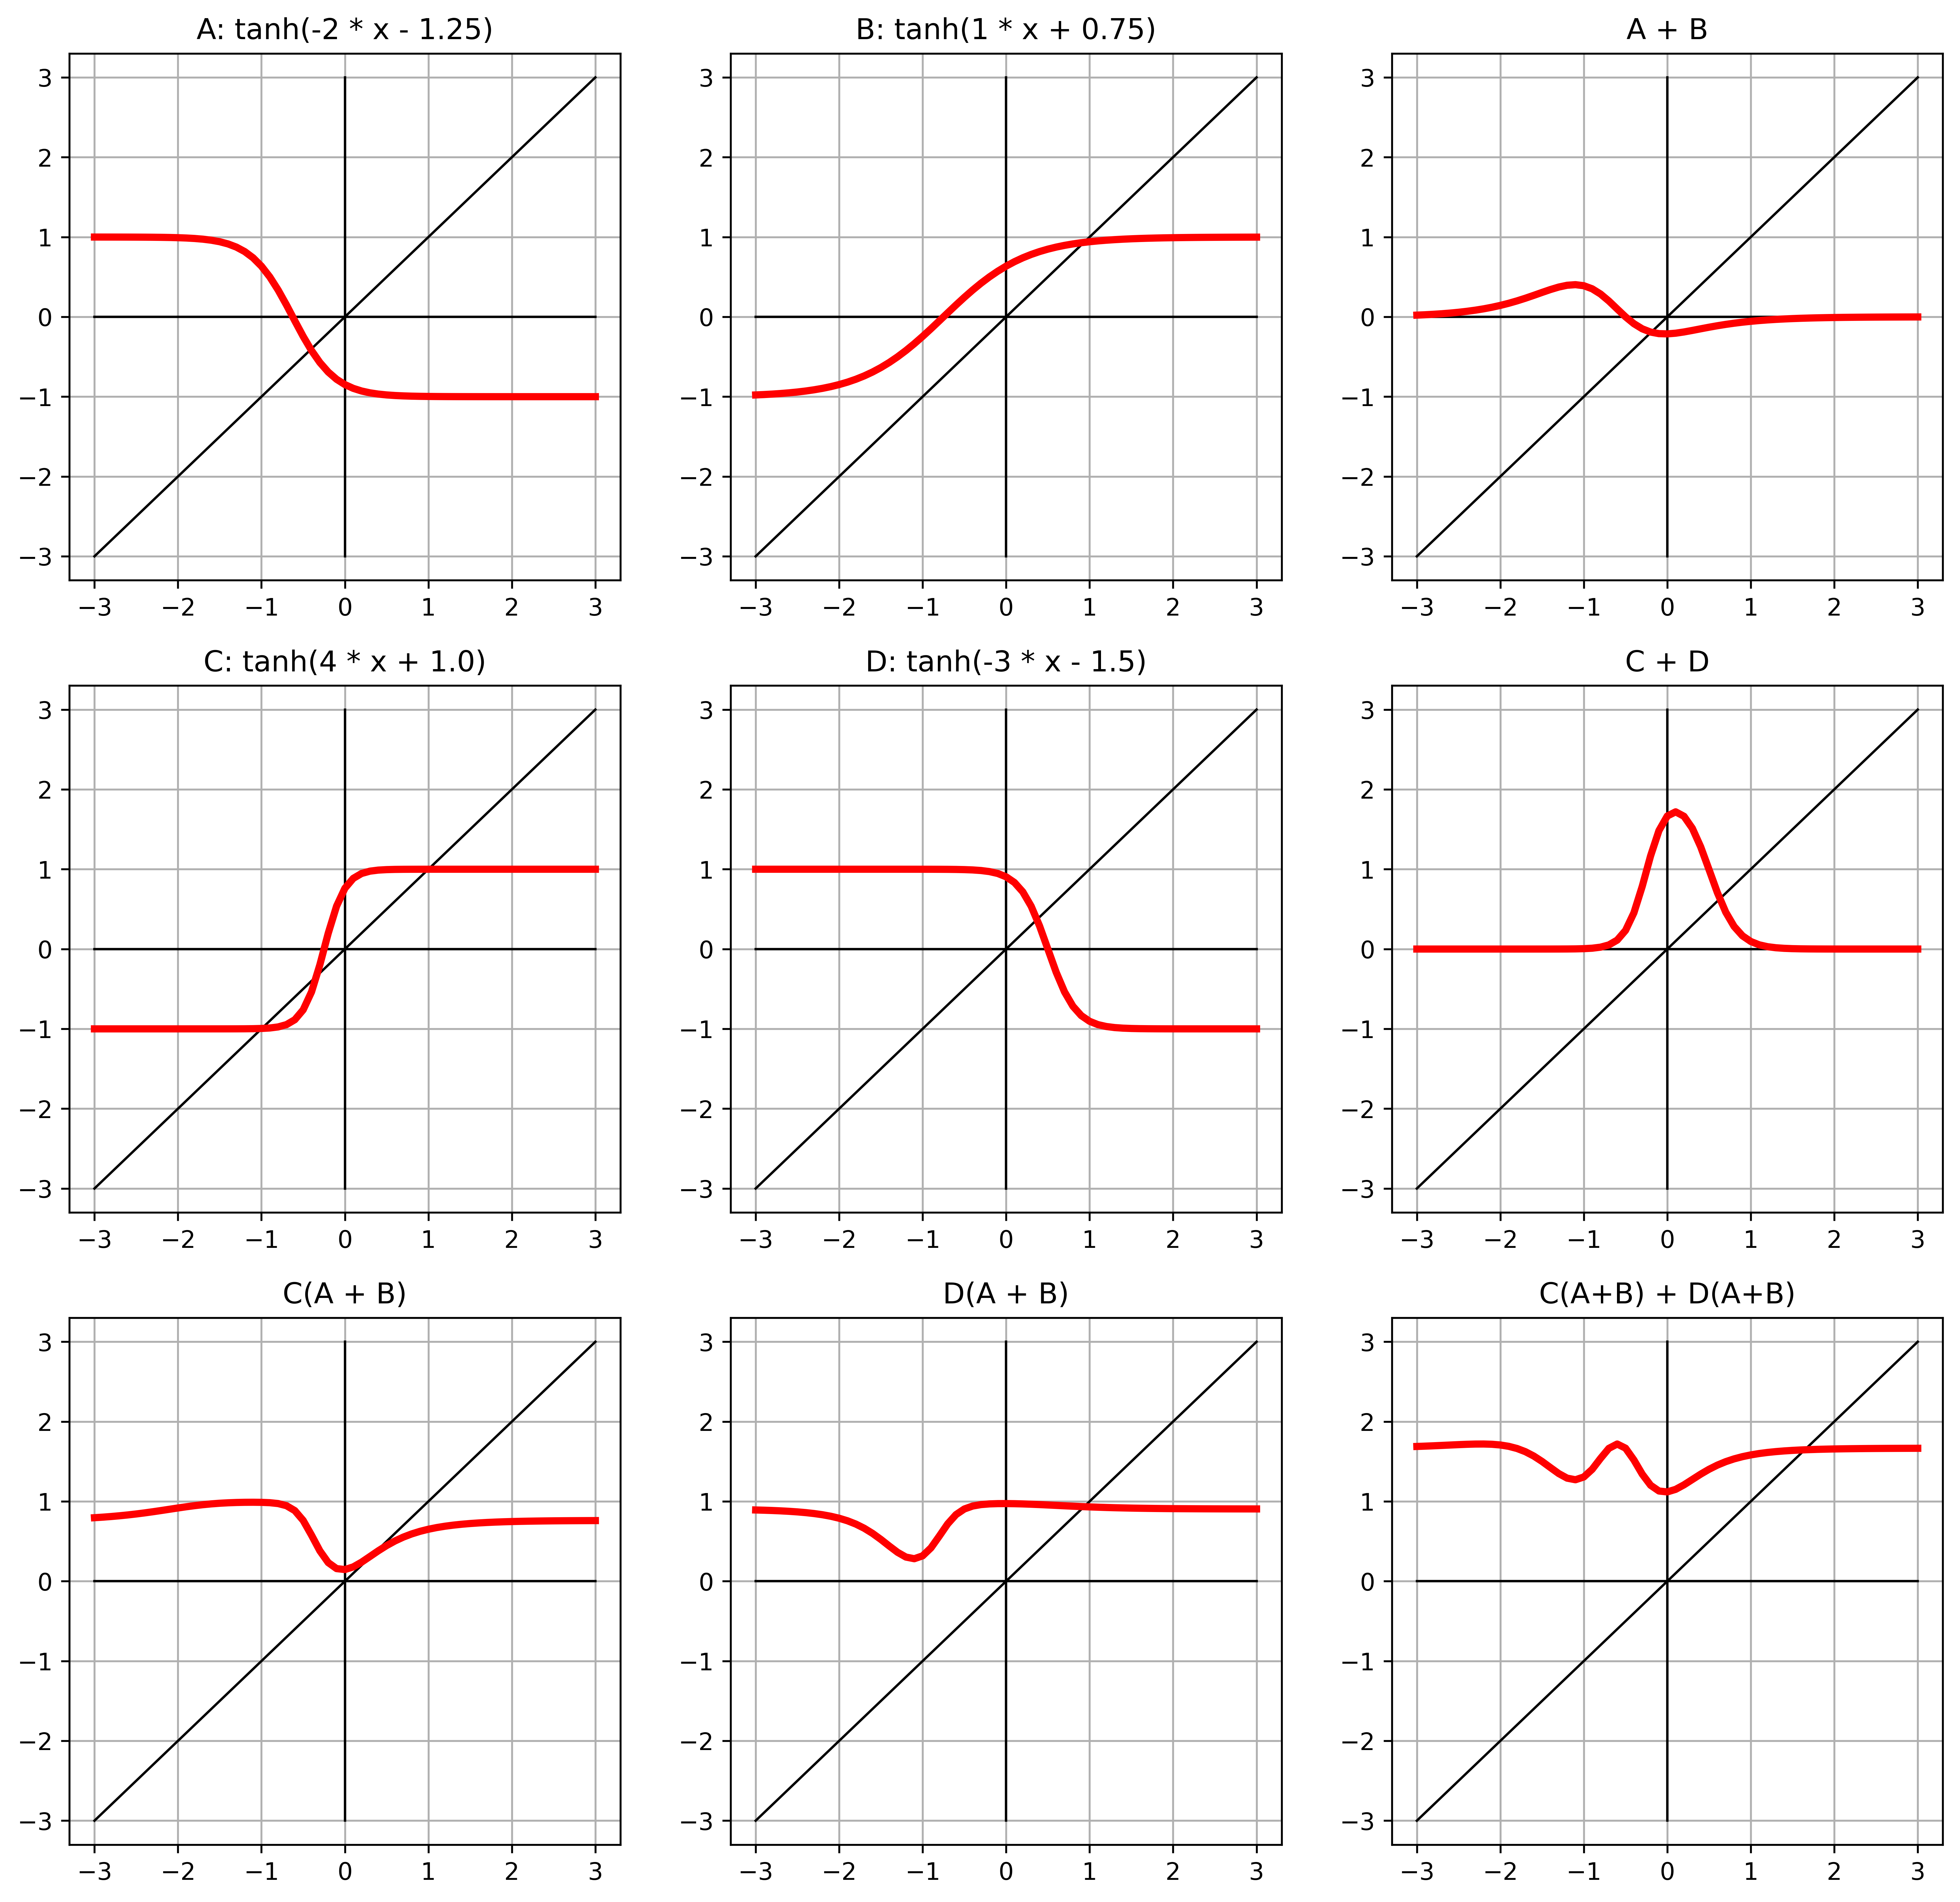

In [4]:
a = lambda x: nn.Tanh()(-2 * x - 1.25)
b = lambda x: nn.Tanh()( 1 * x + 0.75)
c = lambda x: nn.Tanh()( 4 * x + 1.)
d = lambda x: nn.Tanh()(-3 * x + 1.5)

wb_list = [
    ('A: tanh(-2 * x - 1.25)', a(input_t)),
    ('B: tanh(1 * x + 0.75)', b(input_t)),
    ('A + B', a(input_t) + b(input_t)),

    ('C: tanh(4 * x + 1.0)', c(input_t)),
    ('D: tanh(-3 * x - 1.5)', d(input_t)),
    ('C + D', c(input_t) + d(input_t)),

    ('C(A + B)', c(a(input_t) + b(input_t))),
    ('D(A + B)', d(a(input_t) + b(input_t))),
     
    ('C(A+B) + D(A+B)', 
     c(a(input_t) + b(input_t)) + d(a(input_t) + b(input_t))),
]

fig = plt.figure(figsize=(14, 42), dpi=600)

for i, (title_str, output_t) in enumerate(wb_list):
    subplot = fig.add_subplot(len(wb_list), 3, i+1)
    subplot.set_title(title_str)
    
    plt.grid()
    plt.plot(input_t.numpy(), input_t.numpy(),'k', linewidth=1)
    plt.plot([-3,3], [0,0], 'k', linewidth=1)
    plt.plot([0,0], [-3,3], 'k', linewidth=1)
    plt.plot(input_t.numpy(), output_t.numpy(), 'r', linewidth=3)

output_t

In [ ]:
"""
The four top-left graphs show four neurons—A, B, C, and D—each with its own
(arbitrarily chosen) weight and bias. Each neuron uses the Tanh activation function,
with a minimum of -1 and a maximum of 1. The varied weights and biases move the
center point and change how drastically the transition from min to max goes, but they
clearly are all the same general shape. The columns to the right show both pairs of
neurons added together (A+B and then C+D). Here, you start to see some interesting
properties that mimic a single layer of neurons. A+B shows a slight S curve, with the
extremes approaching zero, but both a positive and negative bump in the middle.
Conversely, C+D has only a large positive bump, which peaks at a higher value than
the single-neuron max of 1.

In the third row, you start to compose your neurons as they would be in a two-layer
network. Both C(A+B) and D(A+B) have the same positive-and-negative-bumps that A+B
shows, but the positive peak is more subtle. The composition of C(A+B)+D(A+B) shows a
new property: two clear negative bumps and possibly a subtle second positive peak to the
left of the main area of interest. All this occurs with only four neurons in two layers!

Again, these neurons’ parameters were chosen only to create a visually interesting
result. Training consists of finding acceptable values for these weights and biases so
that the resulting network carries out a task correctly, such as predicting likely temperatures
given geographic coordinates and time of the year. By carrying out a task successfully,
we mean obtaining a correct output on unseen data produced by the same
data-generating process used for training data. A successfully trained network,
through the value of its weights and biases, captures the inherent structure of the data
in the form of meaningful numerical representations that work correctly for previously
unseen data.

Here’s another step in your realization of the mechanics of learning: deep neural
networks allow you to approximate highly nonlinear phenomena without having an
explicit model for them. Instead, starting from a generic, untrained model, you specialize
it on a task by providing it a set of inputs and outputs and a loss function to
backpropagate from. Specializing a generic model to a task by using examples is what
we refer to as learning, because the model wasn’t built with that specific task in mind;
no rules describing how that task worked were encoded in the model.

For your thermometer experience, you assumed that both thermometers measured
temperatures linearly. That assumption is where we implicitly encoded a rule
for our task: we hard-coded the shape of our input/output function; we couldn’t have
approximated anything other than data points sitting around a line. As the dimensionality
of a problem grows (many inputs to many outputs) and input/output relationships
get complicated, assuming a shape for the input/output function is unlikely
to work. The job of a physicist or an applied mathematician is often to come up with a
functional description of a phenomenon from first principles so that it’s possible to
estimate the unknown parameters from measurements and get an accurate model of
the world. Deep neural networks, at the other end, are families of functions that can
approximate a wide range of input/output relationships without necessarily requiring
one to come up with an explanatory model of a phenomenon. In a way, you’re
renouncing an explanation in exchange for the possibility of tackling increasingly
complicated problems. In another way, you sometimes lack the ability, information, or
computational resources to build an explicit model of what you’re presented with, so
data-driven methods are your only way forward.

5.2 The PyTorch nn module
All this talk about neural networks may be getting you curious about building one
from scratch with PyTorch. The first step is replacing your linear model with a neural
network unit. This step is a somewhat-useless step backward from a correctness perspective,
because you’ve already verified that your calibration required only a linear
function, but it’ll still be instrumental for starting a sufficiently simple problem and
scaling up later.

PyTorch has a whole submodule dedicated to neural networks: torch.nn. This submodule
contains the building blocks needed to create all sorts of neural network architectures. 
Those building blocks are called modules in PyTorch parlance (and layers
in other frameworks).

A PyTorch module is a Python class deriving from the nn.Module base class.
A Module can have one or more Parameter instances as attributes, which are tensors
whose values are optimized during the training process. (Think w and b in your
linear model.) A Module can also have one or more submodules (subclasses of
nn.Module) as attributes, and it can track their Parameters as well.

NOTE The submodules must be top-level attributes, not buried inside list or
dict instances! Otherwise, the optimizer won’t be able to locate the submodules
(and, hence, their parameters). For situations in which your model
requires a list or dict of submodules, PyTorch provides nn.ModuleList and
nn.ModuleDict.

Unsurprisingly, you can find a subclass of nn.Module called nn.Linear, which applies
an affine transformation to its input (via the parameter attributes weight and bias);
it’s equivalent to what you implemented earlier in your thermometer experiments.
Now start precisely where you left off and convert your previous code to a form that
uses nn.

All PyTorch-provided subclasses of nn.Module have their call method defined,
which allows you to instantiate an nn.Linear and call it as though it were a function,
as in the following listing.

Refer:  Listing 5.1.png

"""

In [5]:
%matplotlib inline
import numpy as np
import torch
import torch.optim as optim

torch.set_printoptions(edgeitems=2, linewidth=75)

t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c).unsqueeze(1) # Returns a new tensor with a dimension of size one inserted at the specified position.
t_u = torch.tensor(t_u).unsqueeze(1) # 

# t_u.shape

n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples)    # every run indices changes : so alwaus run from the start 

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

# train_indices, val_indices

t_u_train = t_u[train_indices]
t_c_train = t_c[train_indices]

t_u_val = t_u[val_indices]
t_c_val = t_c[val_indices]

t_un_train = 0.1 * t_u_train
t_un_val = 0.1 * t_u_val

In [6]:
import torch.nn as nn

linear_model = nn.Linear(1, 1) # <1> The arguments are input size, output size, and bias defaulting to True.
linear_model(t_un_val)

tensor([[-1.6165],
        [-3.3261]], grad_fn=<AddmmBackward0>)

In [ ]:
"""
Calling an instance of nn.Module with a set of arguments ends up calling a method
named forward with the same arguments. The forward method executes the forward
computation; call does other rather important chores before and after calling
forward. So it’s technically possible to call forward directly, and it produces the same
output as call, but it shouldn’t be done from user code:

Refer : Listing 5.1.1.png

The following listing shows the implementation of Module.call (with some simplifications
made for clarity).

Refer : Listing 5.2.png

As you can see from above listing, a lot of hooks won’t get called properly if you use .forward(…)
directly.

Now turn back to the linear model. The constructor to nn.Linear accepts three
arguments: the number of input features, the number of output features, and
whether the linear model includes a bias (defaulting to True here).

Refer : Listing 5.2.1.png

The number of features in this case refers to the size of the input and the output
tensor for the module, so 1 and 1. If you used both temperature and barometric pressure
in input, for example, you’d have two features in input and one feature in output.
As you’ll see, for more complex models with several intermediate modules, the
number of features is associated with the capacity of the model.

You have an instance of nn.Linear with one input and one output feature, which
requires one weight and one bias:
"""

In [7]:
linear_model.weight

Parameter containing:
tensor([[-0.5228]], requires_grad=True)

In [8]:
linear_model.bias

Parameter containing:
tensor([0.2499], requires_grad=True)

In [ ]:
"""
You can call the module with some input:
"""

In [9]:
x = torch.ones(1)

linear_model(x)

tensor([-0.2729], grad_fn=<AddBackward0>)

In [ ]:
"""
Although PyTorch let you get away with it, you didn’t provide an input with the
right dimensionality. You have a model that takes one input and produces one output,
but PyTorch nn.Module and its subclasses are designed to do so on multiple samples at
the same time. To accommodate multiple samples, modules expect the zeroth dimension
of the input to be the number of samples in the batch.

Any module in nn is written to produce outputs for a batch of multiple inputs at the
same time. Thus, assuming that you need to run nn.Linear on 10 samples, you can
create an input tensor of size B x Nin, where B is the size of the batch and Nin the
number of input features, and run it once through the model:
"""

In [10]:
x = torch.ones(10, 1)

linear_model(x)

tensor([[-0.2729],
        [-0.2729],
        [-0.2729],
        [-0.2729],
        [-0.2729],
        [-0.2729],
        [-0.2729],
        [-0.2729],
        [-0.2729],
        [-0.2729]], grad_fn=<AddmmBackward0>)

In [ ]:
"""
Figure 5.7 shows a similar situation with batched image data. The input is BxCxHxW
with a batch size of three (say, images of a dog, bird, and then car), three channel
dimensions (red, green, and blue), and an unspecified number of pixels for height
and width.
As you can see, the output is a tensor of size B x Nout, where Nout is the number
of output features—four, in this case.

Refer : Figure 5.7 Three RGB images batched together and fed into a neural network.png

The reason we want to do this batching is multi-faceted. One big motivation is to
make sure that the computation we’re asking for is big enough to saturate the computing
resources we’re using to perform the computation. GPUs in particular are highly
parallelized, so a single input on a small model will leave most of the computing units
idle. By providing batches of inputs, the calculation can be spread across the otherwiseidle
units, which means that the batched results come back just as quickly as a single
one would. Another benefit is that some advanced models will use statistical information
from the entire batch, and those statistics get better with larger batch sizes.

The reason we want to do this batching is multi-faceted. One big motivation is to
make sure that the computation we’re asking for is big enough to saturate the computing
resources we’re using to perform the computation. GPUs in particular are highly
parallelized, so a single input on a small model will leave most of the computing units
idle. By providing batches of inputs, the calculation can be spread across the otherwiseidle
units, which means that the batched results come back just as quickly as a single
one would. Another benefit is that some advanced models will use statistical information
from the entire batch, and those statistics get better with larger batch sizes.

Now turn back to the thermometer data. Your t_u and t_c were two 1D tensors of size
B. Thanks to broadcasting, you could write your linear model as w * x + b, where w
and b are two scalar parameters. This model works because you have one input feature;
if you had two, you’d need to add an extra dimension to turn that 1D tensor into
a matrix with samples in the rows and features in the columns.
That’s exactly what you need to do to switch to using nn.Linear. You reshape your
B inputs to B x Nin, where Nin is 1. You can easily do this with unsqueeze:

# In:
t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c).unsqueeze(1)
t_u = torch.tensor(t_u).unsqueeze(1)
t_u.shape

# Out:
torch.Size([11, 1])

You’re done. Now update your training code. First, replace your handmade model
with nn.Linear(1,1); then pass the linear model parameters to the optimizer:

Refer :  Listing 5.7.1.png

"""

In [11]:
linear_model = nn.Linear(1, 1) # <1>
optimizer = optim.SGD(
    linear_model.parameters(), # <2>
    lr=1e-2)

In [ ]:
"""
Earlier, it was your responsibility to create parameters and pass them as the first argument
to optim.SGD. Now you can ask any nn.Module for a list of parameters owned by
it or any of its submodules by using the parameters method:

"""

In [12]:
linear_model.parameters()

<generator object Module.parameters at 0x0000024CBC6432E0>

In [13]:
list(linear_model.parameters())

[Parameter containing:
 tensor([[-0.4618]], requires_grad=True),
 Parameter containing:
 tensor([0.9881], requires_grad=True)]

In [ ]:
"""
This call recurses into submodules defined in the module’s init constructor and
returns a flat list of all parameters encountered, so you can conveniently pass it to the
optimizer constructor as you did earlier.

You can already figure out what happens in the training loop. The optimizer is provided
a list of tensors that were defined with requires_grad = True. All Parameters
are defined this way, by definition, because they need to be optimized by gradient
descent. When training_loss.backward() is called, grad is accumulated on the leaf
nodes of the graph, which are precisely the parameters that were passed to the optimizer.

At this point, the SGD optimizer has everything it needs. When optimizer.step()
is called, it iterates through each Parameter and changes it by an amount proportional
to what is stored in its grad attribute, which is clean design.
Take a look at the training loop now:

Refer : Listing 5.7.2.png
"""

In [14]:
def training_loop(n_epochs, optimizer, model, loss_fn, t_u_train, t_u_val,t_c_train, t_c_val):
    for epoch in range(1, n_epochs + 1):
        t_p_train = model(t_u_train) # <1>
        loss_train = loss_fn(t_p_train, t_c_train)

        t_p_val = model(t_u_val) # <1>
        loss_val = loss_fn(t_p_val, t_c_val)
        
        optimizer.zero_grad()
        loss_train.backward() # <2>
        optimizer.step()

        if epoch == 1 or epoch % 1000 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
                  f" Validation loss {loss_val.item():.4f}")


In [ ]:
"""
The training loop hasn’t changed practically except that now you don’t pass params
explicitly to model because the model itself holds its Parameters internally.

You can use one last bit from torch.nn: the loss. Indeed, nn comes with several
common loss functions, among which nn.MSELoss (MSE stands for Mean Square Error),
which is exactly what you defined earlier as your loss_fn. Loss functions in nn are still
subclasses of nn.Module, so create an instance and call it as a function. In this case,
you get rid of the handwritten loss_fn and replace it:

Refer :  Listing 5.7.3.png
"""

In [15]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

linear_model = nn.Linear(1, 1) # <1>
optimizer = optim.SGD(linear_model.parameters(), lr=1e-2)

training_loop(
    n_epochs = 3000, 
    optimizer = optimizer,
    model = linear_model,
    loss_fn = loss_fn,
    t_u_train = t_un_train,
    t_u_val = t_un_val, 
    t_c_train = t_c_train,
    t_c_val = t_c_val)

print()
print(linear_model.weight)
print(linear_model.bias)

Epoch 1, Training loss 191.8079, Validation loss 233.6297
Epoch 1000, Training loss 3.8258, Validation loss 7.4031
Epoch 2000, Training loss 3.0081, Validation loss 3.9449
Epoch 3000, Training loss 2.9803, Validation loss 3.4339

Parameter containing:
tensor([[5.1390]], requires_grad=True)
Parameter containing:
tensor([-16.1380], requires_grad=True)


In [ ]:
"""
Everything else input into our training loop stays the same. Even our results remain
the same as before. Of course, getting the same results is expected, as a difference
would imply a bug in one of the two implementations.

It’s been a long journey, with a lot to explore for these twenty-something lines of
code. We hope that by now, the magic has vanished and left room for the mechanics.
What you learn in this chapter will allow you to own the code you write instead of
merely poking at a black box when things get more complicated.

You have one last step left to take: replacing your linear model with a neural network
as your approximating function. As we said earlier, using a neural network won’t
result in a higher-quality model, because the process underlying the calibration problem
is fundamentally linear. It’s good to make the leap from linear to neural network
in a controlled environment, however, so that you won’t feel lost later on.

This section keeps everything else fixed, including the loss function, and redefines
only the model. You’ll build the simplest possible neural network: a linear module followed
by an activation function feeding into another linear module. The first linear +
activation layer is commonly referred to as a hidden layer for historical reasons,
because its outputs aren’t observed directly but fed into the output layer. Whereas the
input and the output of the model are both of size 1 (they have one input and one
output feature), the size of the output of the first linear module usually is larger than
one. Recalling the earlier explanation on the role of activations, this situation can
lead different units to respond to different ranges of the input, which increases the
capacity of the model. The last linear layer takes the output of activations and combines
them linearly to produce the output value.

nn provides a simple way to concatenate modules through the nn.Sequential container:

Refer :  Listing 5.7.4.png
"""

In [16]:
seq_model = nn.Sequential(
            nn.Linear(1, 13), # <1>
            nn.Tanh(),
            nn.Linear(13, 1)) # <2>
seq_model

Sequential(
  (0): Linear(in_features=1, out_features=13, bias=True)
  (1): Tanh()
  (2): Linear(in_features=13, out_features=1, bias=True)
)

In [ ]:
"""
The result is a model that takes the inputs expected by the first module specified as an
argument of nn.Sequential, passes intermediate outputs to subsequent modules, and
produces the output returned by the last module. The model fans out from 1 input
feature to 13 hidden features, passes them through a tanh activation, and linearly
combines the resulting 13 numbers into 1 output feature.

Calling model.parameters() collects weight and bias from both the first and the
second linear modules. It’s instructive to inspect the parameters in this case by printing
their shapes:
"""

In [17]:
[param.shape for param in seq_model.parameters()]

[torch.Size([13, 1]), torch.Size([13]), torch.Size([1, 13]), torch.Size([1])]

In [ ]:
"""
These are the tensors that the optimizer will get. Again, after model.backward() is
called, all parameters are populated with their grad, and then the optimizer updates
their values accordingly during the optimizer.step() call, which isn’t too different
from the previous linear model. After all, both models are differentiable models that
can be trained with gradient descent.

A few notes on parameters of nn.Modules: when you’re inspecting parameters of a
model made up of several submodules, it’s handy to be able to identify parameters by
their names. There’s a method for that, called named_parameters:
"""

In [18]:
for name, param in seq_model.named_parameters():
    print(name, param.shape)

0.weight torch.Size([13, 1])
0.bias torch.Size([13])
2.weight torch.Size([1, 13])
2.bias torch.Size([1])


In [ ]:
"""
In fact, the name of each module in Sequential is the ordinal with which the module
appeared in the arguments. Interestingly, Sequential also accepts an OrderedDict4 in
which you can name each module passed to Sequential:

4 Not all versions of Python specify the iteration order for dict, so we’re using OrderedDict here to ensure the
ordering of the layers and emphasize that the order of the layers matters.
"""

In [19]:
from collections import OrderedDict

seq_model = nn.Sequential(OrderedDict([
    ('hidden_linear', nn.Linear(1, 8)),
    ('hidden_activation', nn.Tanh()),
    ('output_linear', nn.Linear(8, 1))
]))

seq_model

Sequential(
  (hidden_linear): Linear(in_features=1, out_features=8, bias=True)
  (hidden_activation): Tanh()
  (output_linear): Linear(in_features=8, out_features=1, bias=True)
)

In [ ]:
"""
This code allows you to get more explanatory names for submodules:
"""

In [20]:
for name, param in seq_model.named_parameters():
    print(name, param.shape)

hidden_linear.weight torch.Size([8, 1])
hidden_linear.bias torch.Size([8])
output_linear.weight torch.Size([1, 8])
output_linear.bias torch.Size([1])


In [ ]:
"""
You can also get to a particular Parameter by accessing submodules as though they
were attributes:
"""

In [21]:
seq_model.output_linear.bias

Parameter containing:
tensor([-0.2923], requires_grad=True)

In [ ]:
"""
This code is useful for inspecting parameters or their gradients, such as to monitor
gradients during training, as you did the beginning of this chapter. Suppose that you
want to print out the gradients of weight of the linear portion of the hidden layer. You
can run the training loop for the new neural network model and then look at the
resulting gradients after the last epoch:
"""

In [22]:
optimizer = optim.SGD(seq_model.parameters(), lr=1e-3) # <1> # Note that the learning rate has 
                                                             # dropped a bitto help with stability.

training_loop(
    n_epochs = 5000, 
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    t_u_train = t_un_train,
    t_u_val = t_un_val, 
    t_c_train = t_c_train,
    t_c_val = t_c_val)
    
print('output', seq_model(t_un_val))
print('answer', t_c_val)
print('hidden', seq_model.hidden_linear.weight.grad)

Epoch 1, Training loss 198.2188, Validation loss 239.4173
Epoch 1000, Training loss 7.0578, Validation loss 5.7136
Epoch 2000, Training loss 4.2143, Validation loss 2.2196
Epoch 3000, Training loss 2.3215, Validation loss 1.7961
Epoch 4000, Training loss 1.9365, Validation loss 2.0349
Epoch 5000, Training loss 1.8583, Validation loss 2.2667
output tensor([[ 2.6060],
        [20.6860]], grad_fn=<AddmmBackward0>)
answer tensor([[ 0.5000],
        [21.0000]])
hidden tensor([[ 8.1655e-07],
        [-1.1725e-02],
        [-4.3801e-04],
        [ 8.0257e-02],
        [ 3.4177e-02],
        [ 4.2958e-03],
        [ 7.6068e-03],
        [-9.7598e-03]])


In [ ]:
"""
You can also evaluate the model on the whole data to see how different it is from a line:
"""

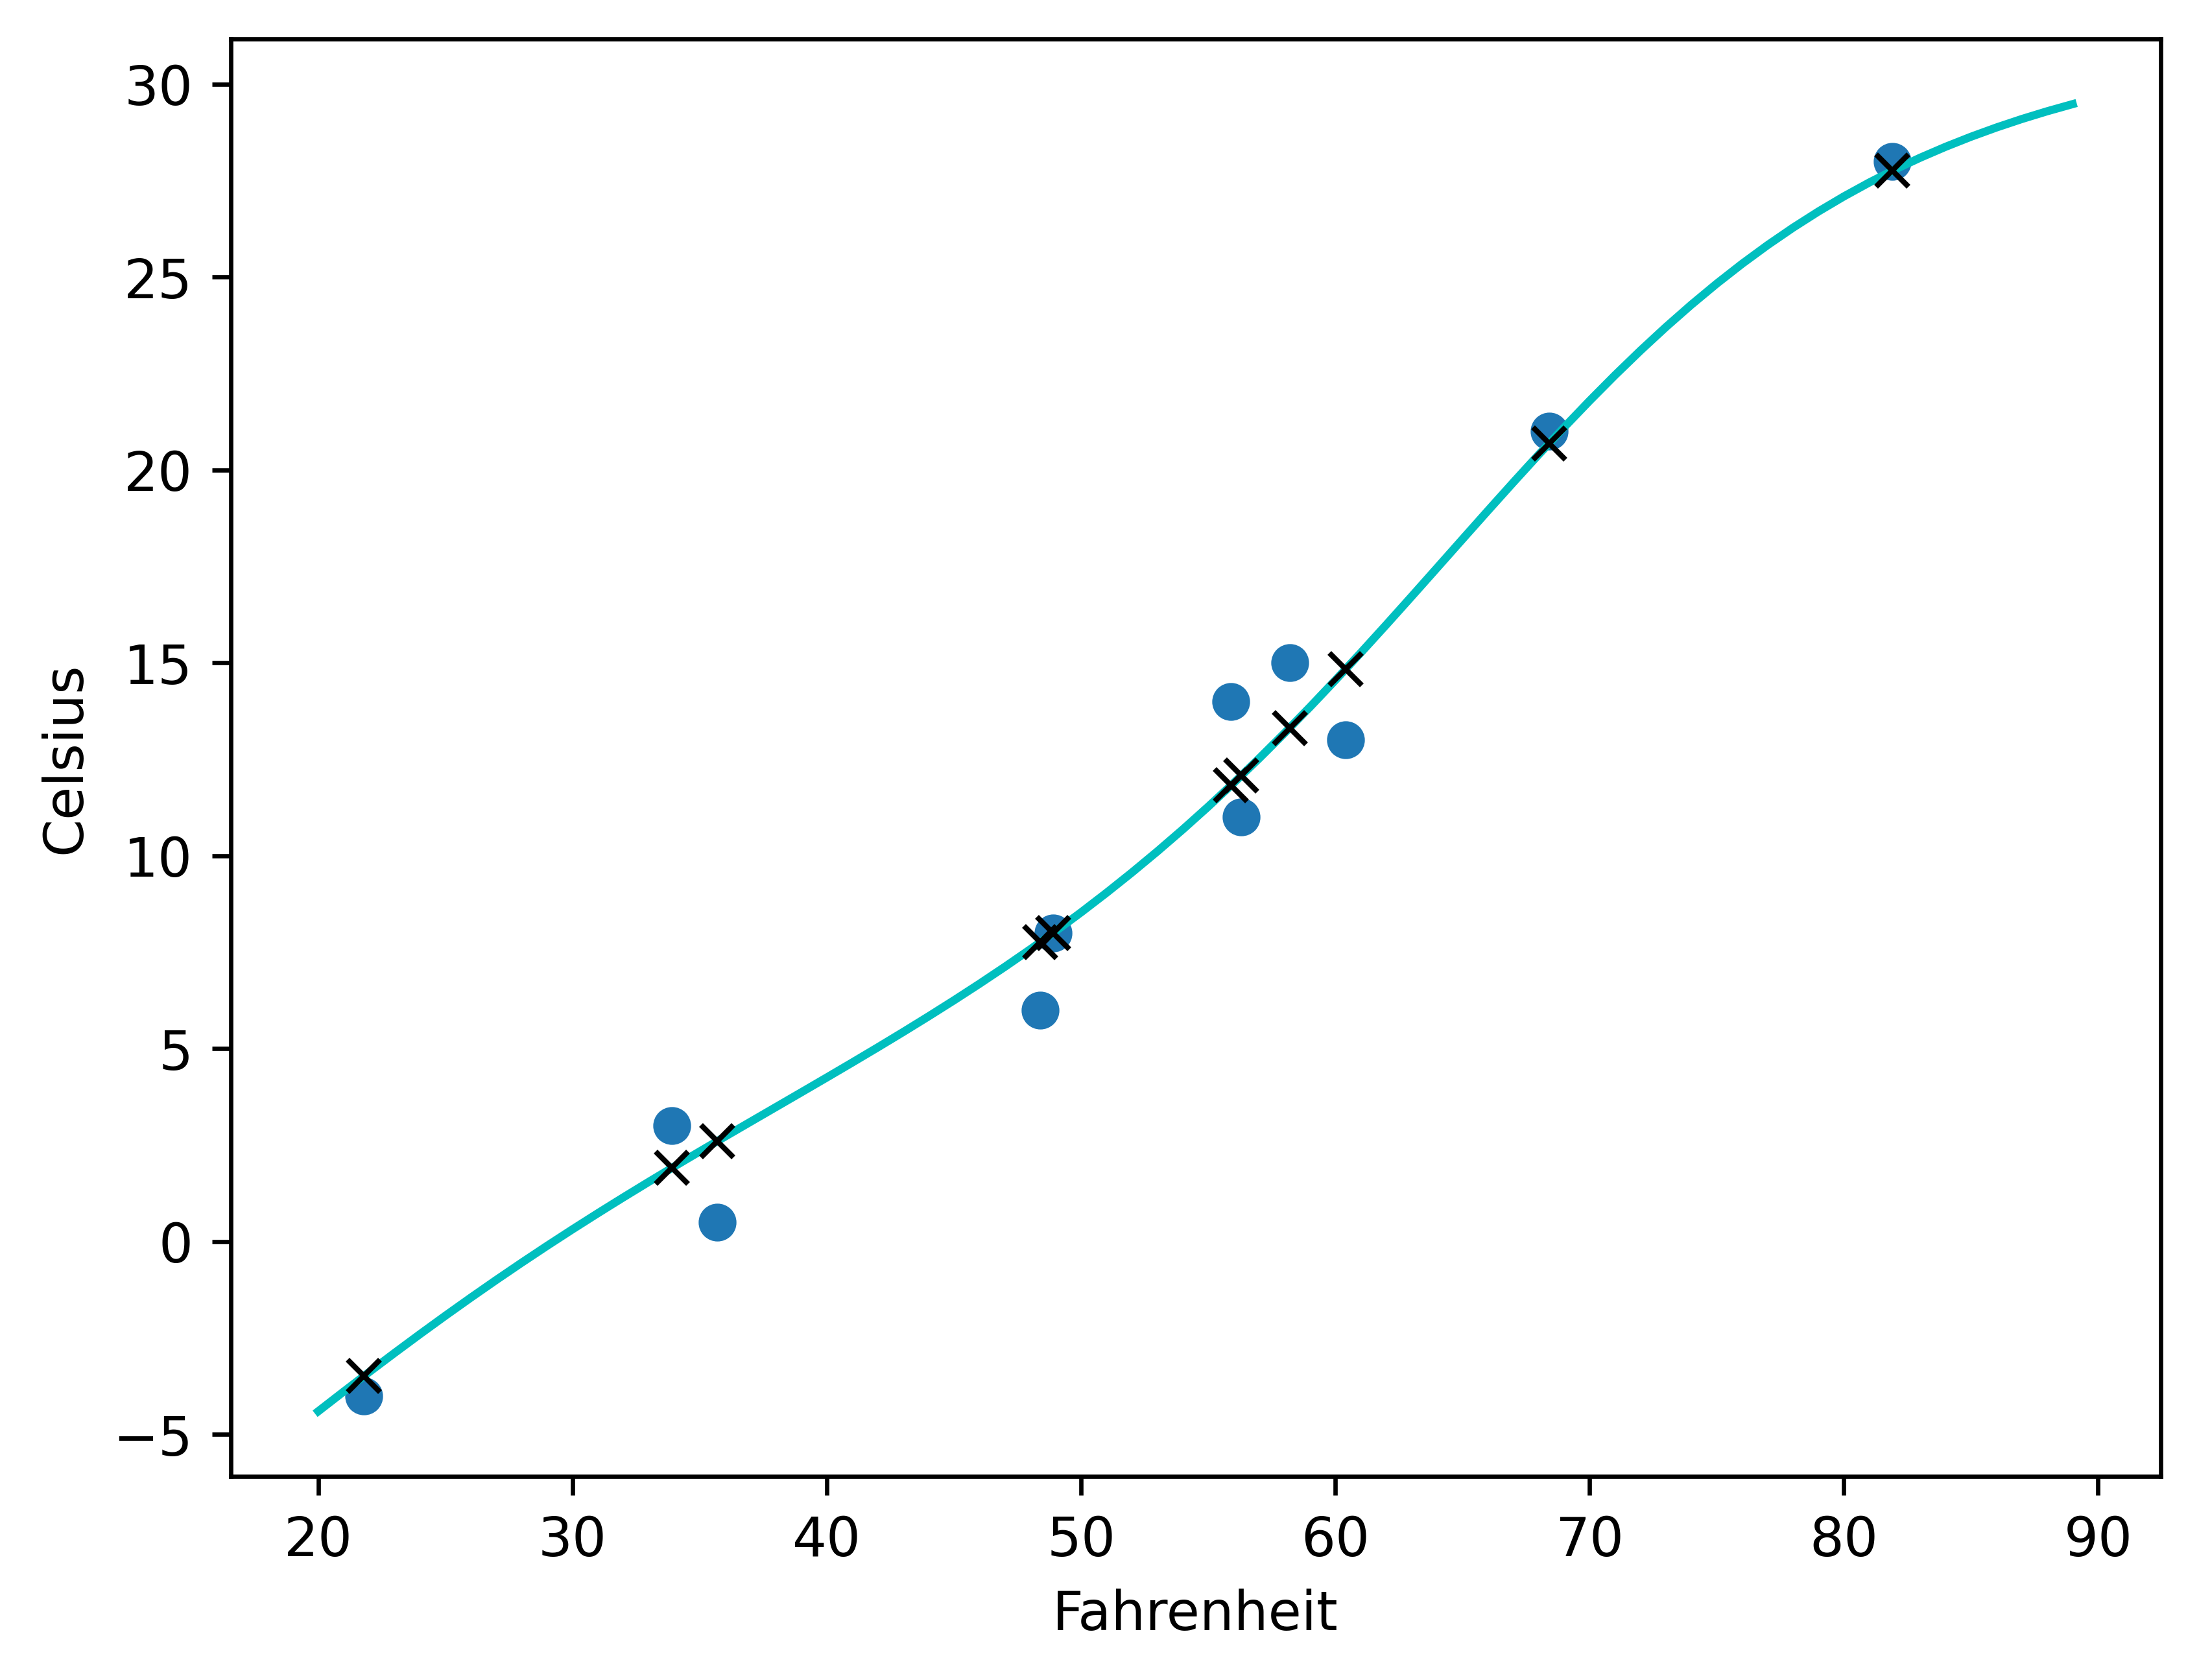

In [23]:
from matplotlib import pyplot as plt

t_range = torch.arange(20., 90.).unsqueeze(1)

fig = plt.figure(dpi=600)
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_model(0.1 * t_range).detach().numpy(), 'c-')
plt.plot(t_u.numpy(), seq_model(0.1 * t_u).detach().numpy(), 'kx')                   # color/marker


In [ ]:
"""
Refer :  Figure 5.8 The plot of the neural network model, with input data (circles), desired output (Xs), and.png

You can appreciate that the neural network has a tendency to overfit because it tries to
chase the measurements, including the noisy ones. It doesn’t do a bad job overall,
though.


5.3 Subclassing nn.Module
For larger and more complex projects, you need to leave nn.Sequential behind in
favor of something that gives you more flexibility: subclassing nn.Module. To subclass
nn.Module, at a minimum you need to define a .forward(…)function that takes the
input to the module and returns the output. If you use standard torch operations,
autograd takes care of the backward pass automatically.

NOTE Often, your entire model is implemented as a subclass of nn.Module,
     which can in turn contain submodules that are also subclasses of nn.Module.
     
We’ll show you three ways to implement the same network structure, using increasingly
more complex PyTorch functionality to do so and varying the number of neurons
in the hidden layer to make it easier to differentiate among the approaches.

The first method is a simple instance of nn.Sequential, as shown in the following
listing.    
    
Refer :  Listing 5.3.png

"""

In [24]:
%matplotlib inline
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn

torch.set_printoptions(edgeitems=2, linewidth=75)

In [25]:
seq_model = nn.Sequential(
            nn.Linear(1, 11), # <1>
            nn.Tanh(),
            nn.Linear(11, 1)) # <1>
seq_model

Sequential(
  (0): Linear(in_features=1, out_features=11, bias=True)
  (1): Tanh()
  (2): Linear(in_features=11, out_features=1, bias=True)
)

In [ ]:
"""
Although this code works, you don’t have any semantic information about what the
various layers are intended to be. You can rectify that situation by giving each layer a
label, using an ordered dictionary instead of a list as input:

"""

In [26]:
from collections import OrderedDict

namedseq_model = nn.Sequential(OrderedDict([
    ('hidden_linear', nn.Linear(1, 12)),
    ('hidden_activation', nn.Tanh()),
    ('output_linear', nn.Linear(12 , 1))
]))

namedseq_model

Sequential(
  (hidden_linear): Linear(in_features=1, out_features=12, bias=True)
  (hidden_activation): Tanh()
  (output_linear): Linear(in_features=12, out_features=1, bias=True)
)

In [ ]:
"""
Much better. You don’t have any ability to control the flow of data through the network,
however, aside from the purely sequential pass-through provided by the (aptly
named!) nn.Sequential class. You can take full control of the processing of input
data by subclassing nn.Module yourself:

"""

In [27]:
class SubclassModel(nn.Module):
    def __init__(self):
        super().__init__()  # <1>
        
        self.hidden_linear = nn.Linear(1, 13)
        self.hidden_activation = nn.Tanh()
        self.output_linear = nn.Linear(13, 1)
        
    def forward(self, input):
        hidden_t = self.hidden_linear(input)
        activated_t = self.hidden_activation(hidden_t)
        output_t = self.output_linear(activated_t)
        
        return output_t
    
subclass_model = SubclassModel()
subclass_model

SubclassModel(
  (hidden_linear): Linear(in_features=1, out_features=13, bias=True)
  (hidden_activation): Tanh()
  (output_linear): Linear(in_features=13, out_features=1, bias=True)
)

In [ ]:
"""
This code ends up being somewhat more verbose, because you have to define the layers
you want to have and then define how and in what order they should be applied in the
forward function. That repetition grants you an incredible amount of flexibility in the
sequential models, however, as you’re now free to do all sorts of interesting things inside
the forward function. Although this example is unlikely to make sense, you could
implement activated_t = self.hidden_activation(hidden_t) if random.random()
> 0.5 else hidden_t to apply the activation function only half the time!
Because PyTorch uses a dynamic graph-based autograd, gradients would flow properly
through the sometimes-present activation, no matter what random.random() returned!

Typically, you want to use the constructor of the module to define the submodules
that we call in the forward function so that they can hold their parameters throughout
the lifetime of your module. You might instantiate two instances of nn.Linear in
the constructor and use them in forward, for example. Interestingly, assigning an
instance of nn.Module to an attribute in a nn.Module, as you did in the constructor
here, automatically registers the module as a submodule, which gives modules access
to the parameters of its submodules without further action by the user.

Going back to the nonrandom SubclassModel, you see that the printed output
for that class is similar to the output for the sequential model with named parameters.
This makes sense, because you used the same names and intended to implement
the same architecture. If you look at the parameters of all three models, you also see
similarities there (except, again, for the differences in the number of hidden neurons):
"""

In [28]:
for type_str, model in [('seq', seq_model),
                        ('namedseq', namedseq_model),
                        ('subclass', subclass_model)]:
    print(type_str)
    for name_str, param in model.named_parameters():
        print("{:21} {:19} {}".format(name_str, str(param.shape), param.numel()))
        
    print()

seq
0.weight              torch.Size([11, 1]) 11
0.bias                torch.Size([11])    11
2.weight              torch.Size([1, 11]) 11
2.bias                torch.Size([1])     1

namedseq
hidden_linear.weight  torch.Size([12, 1]) 12
hidden_linear.bias    torch.Size([12])    12
output_linear.weight  torch.Size([1, 12]) 12
output_linear.bias    torch.Size([1])     1

subclass
hidden_linear.weight  torch.Size([13, 1]) 13
hidden_linear.bias    torch.Size([13])    13
output_linear.weight  torch.Size([1, 13]) 13
output_linear.bias    torch.Size([1])     1



In [ ]:
"""
What happens here is that the named_parameters() call delves into all submodules
assigned as attributes in the constructor and recursively calls named_parameters() on
them. No matter how nested the submodule is, any nn.Module can access the list of
all child parameters. By accessing their grad attribute, which will have been populated
by autograd, the optimizer knows how to change parameters so as to minimize
the loss.

NOTE Child modules contained inside Python list or dict instances won’t
be registered automatically! Subclasses can register those modules manually
with the add_module(name, module) method of nn.Module5 or can use the
provided nn.ModuleList and nn.ModuleDict classes (which provide automatic
registration for contained instances).

Looking back at the implementation of the SubclassModel class, and thinking about
the utility of registering submodules in the constructor so that you can access their
parameters, it appears to be a bit of a waste to also register submodules that have no
parameters, such as nn.Tanh. Wouldn’t it be easier to call them directly in the forward
function?6 It certainly would.

PyTorch has functional counterparts of every nn module. By functional, we mean
“having no internal state” or “whose output value is solely and fully determined by the
value input arguments.” Indeed, torch.nn.functional provides many of the same
modules you find in nn, but with all eventual parameters moved as an argument to the
function call. The functional counterpart of nn.Linear, for example, is nn.functional.
linear, which is a function that has signature linear(input, weight,
bias=None). The weight and bias parameters are arguments to the function.

5 https://pytorch.org/docs/stable/nn.html#torch.nn.Module.add_module
6 Aren’t rhetorical questions great?

To get back to your model, it makes sense to keep using nn modules for nn.Linear
so that SubclassModel can to manage all its Parameter instances during training. You
can safely switch to the functional counterparts of Tanh, however, because it has no
parameters:

Refer  : Listing 5.4.png
"""

In [29]:
class SubclassFunctionalModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.hidden_linear = nn.Linear(1, 14)  
                                                # <1>
        self.output_linear = nn.Linear(14, 1)
        
    def forward(self, input):
        hidden_t = self.hidden_linear(input)
        activated_t = torch.tanh(hidden_t) # <2>
        output_t = self.output_linear(activated_t)
        
        return output_t
    
func_model = SubclassFunctionalModel()
func_model

SubclassFunctionalModel(
  (hidden_linear): Linear(in_features=1, out_features=14, bias=True)
  (output_linear): Linear(in_features=14, out_features=1, bias=True)
)

In [ ]:
"""
The functional version is a bit more concise and fully equivalent to the non-functional
version (as your models get more complicated, the saved lines of code start to add
up!) Note that it would still make sense to instantiate modules that require arguments
for their initialization in the constructor. HardTanh, for example, takes optional
min_val and max_val arguments, and rather than repeatedly state those arguments in
the body of forward, you could create a HardTanh instance and reuse it.

TIP Although general-purpose scientific functions like tanh still exist in
torch.nn.functional in version 1.0, those entry points are deprecated in
favor of ones in the top-level torch namespace. More niche functions remain
in torch.nn.functional.


Conclusion
We covered a lot in this chapter, although we dealt with a simple problem. We dissected
building differentiable models and training them by using gradient descent,
using raw autograd first and then relying on nn. By now, you should have confidence
in your understanding of what’s going on behind the scenes.
"""